Using: cuda
Fixed sigma = 4
Total runs  = 39
Est. time   = 195 min

[1/39] donor_target=20%  actual=20.0%  interface=5.9%
  → Jsc=0.000224  J_var=1.57e-08

[2/39] donor_target=20%  actual=20.0%  interface=7.1%
  → Jsc=0.000000  J_var=3.30e-13

[3/39] donor_target=20%  actual=20.0%  interface=9.5%
  → Jsc=0.003262  J_var=1.20e-06

[4/39] donor_target=25%  actual=25.0%  interface=6.5%
  → Jsc=0.002858  J_var=1.97e-06

[5/39] donor_target=25%  actual=25.0%  interface=9.4%
  → Jsc=0.001091  J_var=6.20e-07

[6/39] donor_target=25%  actual=25.0%  interface=11.0%
  → Jsc=0.004173  J_var=2.21e-06

[7/39] donor_target=30%  actual=30.0%  interface=7.4%
  → Jsc=0.000004  J_var=3.68e-07

[8/39] donor_target=30%  actual=30.0%  interface=10.4%
  → Jsc=0.005077  J_var=1.16e-06

[9/39] donor_target=30%  actual=30.0%  interface=12.0%
  → Jsc=0.005242  J_var=1.71e-06

[10/39] donor_target=35%  actual=35.1%  interface=9.9%
  → Jsc=0.016815  J_var=3.17e-06

[11/39] donor_target=35%  actual=35.1%  interfac

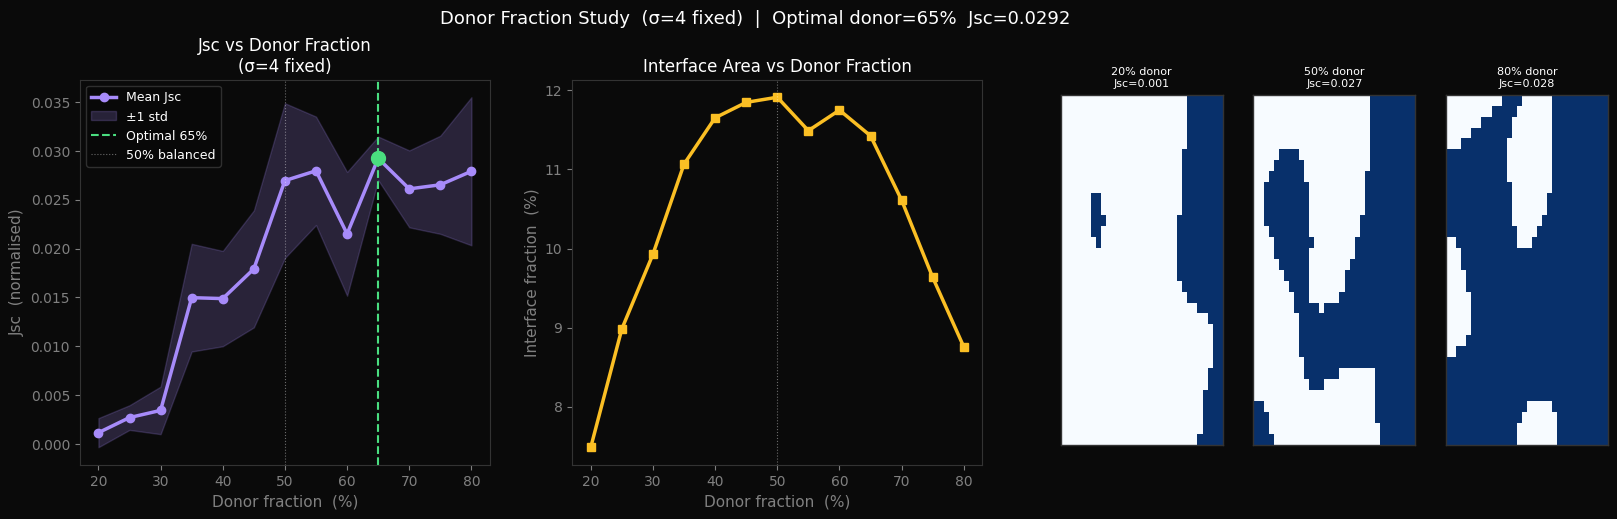

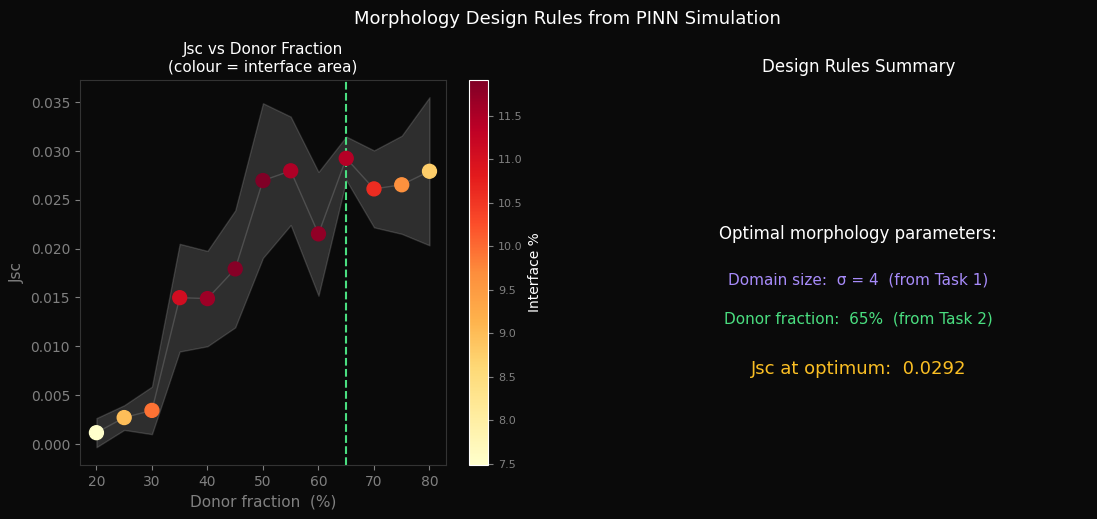


Results saved to donor_fraction_results.npy


In [1]:
# ============================================
# TASK 2: DONOR FRACTION STUDY
# Fix sigma=4 (good percolation), vary donor%
# from 20% to 80% by changing threshold
# ============================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

# ============================================
# CONSTANTS
# ============================================
N_grid = 32
q      = 1.0
Vt     = 0.025
mu_n   = 1.0
mu_p   = 1.0
mu_X   = 1.0
k_rec  = 0.1
k_diss = 5.0
G      = 0.1
alpha  = 3.0

# ============================================
# NETWORK — identical to Task 1
# ============================================
def make_net(hidden=128):
    net = nn.Sequential(
        nn.Linear(3, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, 1)
    )
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    return net

class PINN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi_net = make_net()
        self.n_net   = make_net()
        self.p_net   = make_net()
        self.X_net   = make_net()

    def forward(self, coords, M):
        inp = torch.cat([coords, M], dim=1)
        x   = coords[:, 0:1]
        phi = x  +  x * (1 - x) * self.phi_net(inp)
        n   = (1 - x) * torch.nn.functional.softplus(self.n_net(inp))
        p   = x       * torch.nn.functional.softplus(self.p_net(inp) + 1.0)
        X   =           torch.nn.functional.softplus(self.X_net(inp))
        return phi, n, p, X

def grad(f, coords):
    return torch.autograd.grad(
        f, coords,
        grad_outputs=torch.ones_like(f),
        create_graph=True, retain_graph=True)[0]

def laplacian(f, coords):
    g   = grad(f, coords)
    gxx = grad(g[:, 0:1], coords)[:, 0:1]
    gyy = grad(g[:, 1:2], coords)[:, 1:2]
    return gxx + gyy

def divergence(Fx, Fy, coords):
    return (grad(Fx, coords)[:, 0:1] +
            grad(Fy, coords)[:, 1:2])

def fresh_coords():
    x_lin  = torch.linspace(0, 1, N_grid)
    y_lin  = torch.linspace(0, 1, N_grid)
    Xg, Yg = torch.meshgrid(x_lin, y_lin, indexing='ij')
    c = torch.stack([Xg, Yg], dim=-1).reshape(-1, 2).to(device)
    c.requires_grad_(True)
    return c

def interface_fraction(M):
    h = np.abs(np.diff(M, axis=0)).sum()
    v = np.abs(np.diff(M, axis=1)).sum()
    return (h + v) / M.size

def make_morphology_at_fraction(donor_fraction, sigma=4, seed=42):
    """Generate BHJ morphology with exact donor fraction."""
    np.random.seed(seed)
    noise     = np.random.randn(N_grid, N_grid)
    smoothed  = gaussian_filter(noise, sigma=sigma)
    # threshold at (1 - donor_fraction) percentile
    # so donor_fraction% of pixels become donor (=1)
    threshold = np.percentile(smoothed, (1 - donor_fraction) * 100)
    return (smoothed > threshold).astype(float)

def compute_all(coords, M_flat, model):
    phi, n, p, X = model(coords, M_flat)

    grad_phi = grad(phi, coords)
    grad_n   = grad(n,   coords)
    grad_p   = grad(p,   coords)
    grad_X   = grad(X,   coords)
    lap_phi  = laplacian(phi, coords)
    lap_X    = laplacian(X,   coords)

    Jn_x = -q*n*mu_n*grad_phi[:,0:1] + q*Vt*mu_n*grad_n[:,0:1]
    Jn_y = -q*n*mu_n*grad_phi[:,1:2] + q*Vt*mu_n*grad_n[:,1:2]
    Jp_x = -q*p*mu_p*grad_phi[:,0:1] - q*Vt*mu_p*grad_p[:,0:1]
    Jp_y = -q*p*mu_p*grad_phi[:,1:2] - q*Vt*mu_p*grad_p[:,1:2]

    div_Jn    = divergence(Jn_x, Jn_y, coords)
    div_Jp    = divergence(Jp_x, Jp_y, coords)
    R         = k_rec  * n * p
    R_X       = k_rec  * X
    field_mag = torch.norm(grad_phi, dim=1, keepdim=True)
    D_term    = k_diss * X * field_mag
    G_field   = G * M_flat

    L_p = torch.mean((lap_phi - q*(n - p))**2)
    L_e = torch.mean((div_Jn  - R + D_term)**2)
    L_h = torch.mean((-div_Jp - R + D_term)**2)
    L_x = torch.mean((Vt*mu_X*lap_X - D_term - R_X + G_field)**2)

    y_c    = coords[:, 1]
    y0     = y_c < (1.0/N_grid)
    y1     = y_c > (1.0 - 1.0/N_grid)
    L_xbc  = (torch.mean(grad_X[y0, 1:2]**2) +
               torch.mean(grad_X[y1, 1:2]**2))
    L_pbc  = (torch.mean(grad_phi[y0, 1:2]**2) +
               torch.mean(grad_phi[y1, 1:2]**2))
    L_nd   = torch.mean((n * M_flat)**2)
    L_pd   = torch.mean((p * (1 - M_flat))**2)
    L_cons = torch.var(Jn_x + Jp_x)

    return (L_p, L_e, L_h, L_x, L_xbc,
            L_pbc, L_nd, L_pd, L_cons, Jn_x, Jp_x)

def train_and_get_Jsc(M_np):
    M_flat = torch.tensor(
        M_np.flatten(), dtype=torch.float32
    ).reshape(-1, 1).to(device)

    model = PINN2D().to(device)

    # Phase 1
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(2000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, *_ = compute_all(c, M_flat, model)
        L_p.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    # Phase 2
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    for epoch in range(3000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, L_e, L_h, *_ = compute_all(c, M_flat, model)
        loss = L_p + L_e + L_h
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    # Phase 3
    opt = torch.optim.Adam(model.parameters(), lr=2e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=2000)
    for epoch in range(15000):
        opt.zero_grad()
        c = fresh_coords()
        (L_p, L_e, L_h, L_x, L_xbc,
         L_pbc, L_nd, L_pd,
         L_cons, Jn_x, Jp_x) = compute_all(c, M_flat, model)

        loss = (  1.0*L_p  + 1.0*L_e  + 5.0*L_h
                + 1.0*L_x  + 5.0*L_xbc + 5.0*L_pbc
                + 10.0*L_nd + 10.0*L_pd + 50.0*L_cons)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sch.step()

    # Evaluate
    model.eval()
    c_eval = fresh_coords()
    phi_v, n_v, p_v, X_v = model(c_eval, M_flat)
    gp  = grad(phi_v, c_eval)
    gn  = grad(n_v,   c_eval)
    gpp = grad(p_v,   c_eval)
    Jn_x_v = -q*n_v*mu_n*gp[:,0:1] + q*Vt*mu_n*gn[:,0:1]
    Jp_x_v = -q*p_v*mu_p*gp[:,0:1] - q*Vt*mu_p*gpp[:,0:1]
    Jtot   =  Jn_x_v + Jp_x_v
    Jsc    = -float(Jtot.reshape(N_grid,N_grid)[-1,:].mean().detach())
    J_var  = float(torch.var(Jtot).detach())

    fields = {
        'n': n_v.detach().cpu().numpy().reshape(N_grid, N_grid),
        'p': p_v.detach().cpu().numpy().reshape(N_grid, N_grid),
        'X': X_v.detach().cpu().numpy().reshape(N_grid, N_grid),
        'M': M_np,
    }

    return max(Jsc, 0.0), J_var, fields

# ============================================
# SWEEP DONOR FRACTION — 3 SEEDS EACH
# ============================================
donor_fractions = [0.20, 0.25, 0.30, 0.35, 0.40,
                   0.45, 0.50, 0.55, 0.60, 0.65,
                   0.70, 0.75, 0.80]
seeds           = [42, 123, 777]
sigma_fixed     = 4   # fixed at medium domain size

Jsc_all   = {f: [] for f in donor_fractions}
intf_all  = {f: [] for f in donor_fractions}
fields_50 = None   # save fields at 50% for visualization

total_runs = len(donor_fractions) * len(seeds)
run_count  = 0

print(f"Fixed sigma = {sigma_fixed}")
print(f"Total runs  = {total_runs}")
print(f"Est. time   = {total_runs * 5} min\n")

for df in donor_fractions:
    for seed in seeds:
        run_count += 1
        M_np = make_morphology_at_fraction(df, sigma_fixed, seed)
        intf = interface_fraction(M_np)
        actual_donor = M_np.mean()

        print(f"[{run_count}/{total_runs}] "
              f"donor_target={df:.0%}  "
              f"actual={actual_donor:.1%}  "
              f"interface={intf:.1%}")

        Jsc, J_var, fields = train_and_get_Jsc(M_np)

        Jsc_all[df].append(Jsc)
        intf_all[df].append(intf)

        if abs(df - 0.50) < 0.01 and seed == 42:
            fields_50 = fields
            fields_50['M'] = M_np

        print(f"  → Jsc={Jsc:.6f}  J_var={J_var:.2e}\n")

# ============================================
# STATISTICS
# ============================================
df_vals    = np.array(donor_fractions) * 100
Jsc_mean   = np.array([np.mean(Jsc_all[f])  for f in donor_fractions])
Jsc_std    = np.array([np.std(Jsc_all[f])   for f in donor_fractions])
intf_mean  = np.array([np.mean(intf_all[f]) for f in donor_fractions])

idx_opt    = np.argmax(Jsc_mean)
df_opt     = donor_fractions[idx_opt]
Jsc_opt    = Jsc_mean[idx_opt]

print(f"\n{'='*55}")
print(f"{'Donor%':>8} {'Interface%':>12} "
      f"{'Jsc mean':>10} {'Jsc std':>10}")
print(f"{'-'*55}")
for i, df in enumerate(donor_fractions):
    marker = " ← OPTIMAL" if df == df_opt else ""
    print(f"{df:>8.0%} {intf_mean[i]:>12.1%} "
          f"{Jsc_mean[i]:>10.4f} "
          f"{Jsc_std[i]:>10.4f}{marker}")
print(f"{'='*55}")
print(f"\nOptimal donor fraction = {df_opt:.0%}  "
      f"Jsc={Jsc_opt:.4f}")

# ============================================
# VISUALIZATION
# ============================================
BG = '#0a0a0a'
plt.style.use('dark_background')
x_ax = np.linspace(0, 1, N_grid)
y_ax = np.linspace(0, 1, N_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)

# --- Panel 1: Jsc vs donor fraction ---
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(df_vals, Jsc_mean,
        color='#a78bfa', linewidth=2.5,
        marker='o', markersize=6,
        label='Mean Jsc')
ax.fill_between(df_vals,
                Jsc_mean - Jsc_std,
                Jsc_mean + Jsc_std,
                alpha=0.2, color='#a78bfa',
                label='±1 std')
ax.axvline(x=df_opt*100, color='#4ade80',
           linewidth=1.5, linestyle='--',
           label=f'Optimal {df_opt:.0%}')
ax.scatter([df_opt*100], [Jsc_opt],
           color='#4ade80', s=100, zorder=5)
ax.axvline(x=50, color='white', linewidth=0.8,
           linestyle=':', alpha=0.4, label='50% balanced')
ax.set_xlabel('Donor fraction  (%)', color='gray', fontsize=11)
ax.set_ylabel('Jsc  (normalised)', color='gray', fontsize=11)
ax.set_title('Jsc vs Donor Fraction\n(σ=4 fixed)',
             color='white', fontsize=12)
ax.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax.tick_params(colors='gray')
for s in ax.spines.values(): s.set_edgecolor('#333333')

# --- Panel 2: Interface fraction vs donor fraction ---
ax2 = axes[1]
ax2.set_facecolor(BG)
ax2.plot(df_vals, intf_mean*100,
         color='#fbbf24', linewidth=2.5,
         marker='s', markersize=6)
ax2.axvline(x=50, color='white', linewidth=0.8,
            linestyle=':', alpha=0.4)
ax2.set_xlabel('Donor fraction  (%)', color='gray', fontsize=11)
ax2.set_ylabel('Interface fraction  (%)', color='gray', fontsize=11)
ax2.set_title('Interface Area vs Donor Fraction',
              color='white', fontsize=12)
ax2.tick_params(colors='gray')
for s in ax2.spines.values(): s.set_edgecolor('#333333')

# --- Panel 3: Example morphologies at 20%, 50%, 80% ---
ax3 = axes[2]
ax3.axis('off')
ax3.set_facecolor(BG)

example_fracs = [0.20, 0.50, 0.80]
for k, ef in enumerate(example_fracs):
    left   = 0.67 + k * 0.107
    bottom = 0.15
    width  = 0.09
    height = 0.70
    inner  = fig.add_axes([left, bottom, width, height])
    inner.set_facecolor(BG)
    M_ex = make_morphology_at_fraction(ef, sigma_fixed, 42)
    inner.pcolormesh(x_ax, y_ax, M_ex.T,
                     cmap='Blues', shading='auto',
                     vmin=0, vmax=1)
    jsc_ex = Jsc_mean[donor_fractions.index(ef)] \
             if ef in donor_fractions else 0.0
    inner.set_title(f'{ef:.0%} donor\nJsc={jsc_ex:.3f}',
                    color='white', fontsize=8)
    inner.set_xticks([])
    inner.set_yticks([])
    col = '#4ade80' if ef == df_opt else '#333333'
    lw  = 2 if ef == df_opt else 1
    for spine in inner.spines.values():
        spine.set_edgecolor(col)
        spine.set_linewidth(lw)

fig.suptitle(
    f'Donor Fraction Study  (σ={sigma_fixed} fixed)  |  '
    f'Optimal donor={df_opt:.0%}  Jsc={Jsc_opt:.4f}',
    color='white', fontsize=13, y=1.02
)
plt.savefig('donor_fraction_study.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

# ============================================
# COMBINED INSIGHT PLOT
# ============================================
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.patch.set_facecolor(BG)

# Jsc vs donor% with interface% as colour
ax = axes2[0]
ax.set_facecolor(BG)
sc = ax.scatter(df_vals, Jsc_mean,
                c=intf_mean*100, cmap='YlOrRd',
                s=100, zorder=5)
ax.plot(df_vals, Jsc_mean,
        color='gray', linewidth=1, alpha=0.4)
ax.fill_between(df_vals,
                Jsc_mean - Jsc_std,
                Jsc_mean + Jsc_std,
                alpha=0.15, color='white')
plt.colorbar(sc, ax=ax,
             label='Interface %').ax.tick_params(
             colors='gray', labelsize=8)
ax.axvline(x=df_opt*100, color='#4ade80',
           linestyle='--', linewidth=1.5)
ax.set_xlabel('Donor fraction  (%)', color='gray', fontsize=11)
ax.set_ylabel('Jsc', color='gray', fontsize=11)
ax.set_title('Jsc vs Donor Fraction\n(colour = interface area)',
             color='white', fontsize=11)
ax.tick_params(colors='gray')
for s in ax.spines.values(): s.set_edgecolor('#333333')

# Both studies together — σ effect and donor effect
ax2 = axes2[1]
ax2.set_facecolor(BG)
ax2.text(0.5, 0.60,
         f'Optimal morphology parameters:',
         ha='center', va='center',
         color='white', fontsize=12,
         transform=ax2.transAxes)
ax2.text(0.5, 0.48,
         f'Domain size:  σ = {sigma_fixed}  (from Task 1)',
         ha='center', va='center',
         color='#a78bfa', fontsize=11,
         transform=ax2.transAxes)
ax2.text(0.5, 0.38,
         f'Donor fraction:  {df_opt:.0%}  (from Task 2)',
         ha='center', va='center',
         color='#4ade80', fontsize=11,
         transform=ax2.transAxes)
ax2.text(0.5, 0.25,
         f'Jsc at optimum:  {Jsc_opt:.4f}',
         ha='center', va='center',
         color='#fbbf24', fontsize=13,
         transform=ax2.transAxes)
ax2.set_title('Design Rules Summary',
              color='white', fontsize=12)
ax2.axis('off')

fig2.suptitle('Morphology Design Rules from PINN Simulation',
              color='white', fontsize=13, y=1.02)
plt.savefig('donor_fraction_insight.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

# Save results
np.save('donor_fraction_results.npy', {
    'donor_fractions': donor_fractions,
    'Jsc_mean':        Jsc_mean,
    'Jsc_std':         Jsc_std,
    'intf_mean':       intf_mean,
    'sigma_fixed':     sigma_fixed,
    'df_opt':          df_opt,
    'Jsc_opt':         Jsc_opt,
})
print("\nResults saved to donor_fraction_results.npy")